/tmp/ipykernel_56156/3678355839.py:37: PyVistaDeprecationWarning: ``max_time`` parameter is deprecated.  It will be removed in v0.48
  streamlines = mesh.streamlines(
/tmp/ipykernel_56156/3678355839.py:53: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  plotter.show()


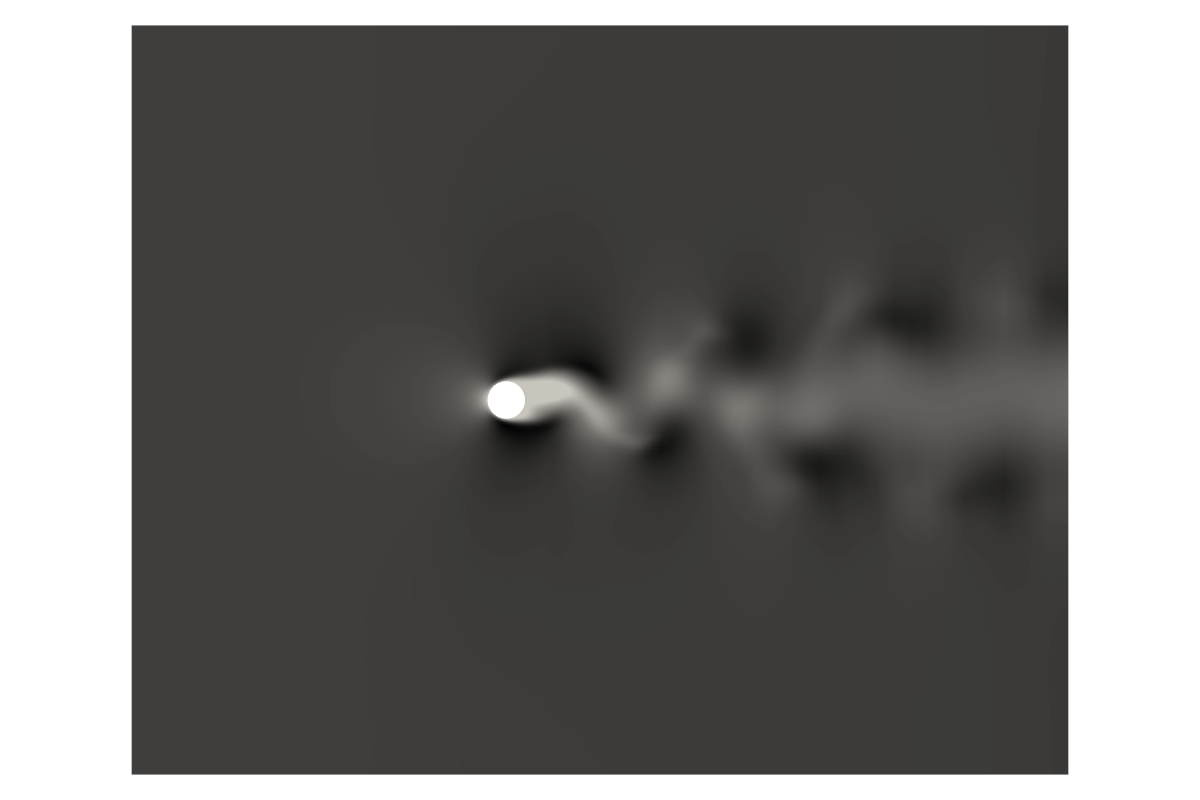

In [7]:
import pyvista as pv
import numpy as np

def plot_streaklines(vtk_file, output_file="streaklines.png"):

    # --- Load data ---
    data = pv.read(vtk_file)

    if isinstance(data, pv.MultiBlock):
        mesh = data.combine()
    else:
        mesh = data

    mesh = mesh.cell_data_to_point_data()

    if "U" not in mesh.array_names:
        raise ValueError("Velocity field 'U' not found")

    # --- High-resolution off-screen plotter ---
    plotter = pv.Plotter(
        border=False,
        window_size=(2800, 1200),   # higher resolution
        off_screen=True             # required for saving without GUI
    )

    plotter.set_background("black")
    plotter.enable_anti_aliasing()

    # --- Seed line ---
    bounds = mesh.bounds
    x_min, x_max, y_min, y_max, _, _ = bounds

    line = pv.Line(
        pointa=(x_min + 0.03*(x_max - x_min), y_min, 0),
        pointb=(x_min + 0.03*(x_max - x_min), y_max, 0),
        resolution=600
    )

    # --- Streamlines ---
    streamlines = mesh.streamlines_from_source(
        line,
        vectors="U",
        max_time=500,
        initial_step_length=0.2,
        integration_direction="forward"
    )

    # --- Tube for thickness ---
    tubes = streamlines.tube(radius=0.002)

    plotter.add_mesh(
        tubes,
        color="white",
        smooth_shading=True,
        ambient=0.8,
        diffuse=0.2,
        specular=0.1
    )

    # --- Glow layer ---
    glow = streamlines.tube(radius=0.006)
    plotter.add_mesh(
        glow,
        color="white",
        opacity=0.08
    )

    # --- Camera ---
    plotter.view_xy()
    plotter.camera.parallel_projection = True
    plotter.reset_camera()
    plotter.camera.zoom(1.5)

    # --- Render and save ---
    plotter.show(auto_close=False)  # required before screenshot
    plotter.screenshot(output_file, scale=2)  # supersampling
    plotter.close()

plot_velocity_bw("Data/VTK/caseIcoFoam_20000.vtm")